In [ ]:
                               # MAINCRAFT TASK 2 - TITANIC DATA ANALYSIS

In [1]:
 #Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
 #Loading Dataset
df = pd.read_csv("train.csv")

In [3]:
#Show First 5 Rows
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [4]:
#Basic Information
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [5]:
#Checking Missing Values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [6]:
#Handle Missing Values

# Filling missing Age values with median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Filling Embarked missing values with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Droping Cabin column because too many missing values
df.drop(columns='Cabin', inplace=True)

# Check again
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_11626/1696987524.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_11626/1696987524.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 


Survival Rate by Gender:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


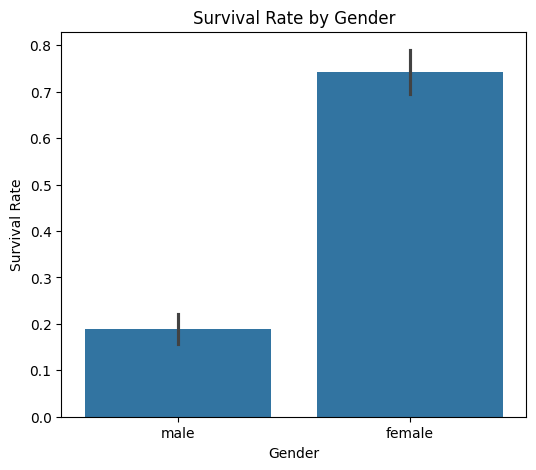

In [7]:
##QUESTION 1: Who survived more?

gender_survival = df.groupby('Sex')['Survived'].mean()

print("\nSurvival Rate by Gender:")
print(gender_survival)

# Visualization
plt.figure(figsize=(6,5))
sns.barplot(x='Sex', y='Survived', data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()


Survival Rate by Passenger Class:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


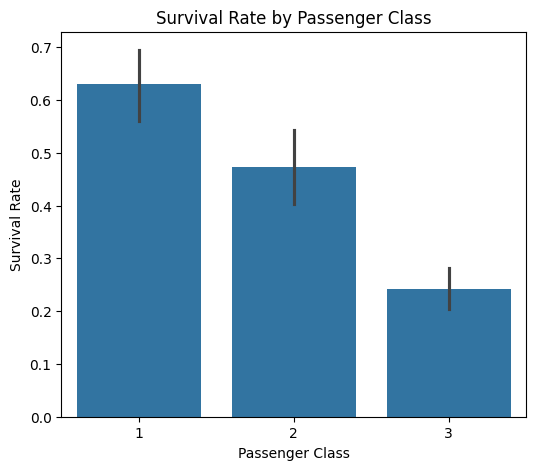

In [8]:
##Question 2: Did passenger class affect survival?

class_survival = df.groupby('Pclass')['Survived'].mean()

print("\nSurvival Rate by Passenger Class:")
print(class_survival)

# Visualization
plt.figure(figsize=(6,5))
sns.barplot(x='Pclass', y='Survived', data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

/tmp/ipykernel_11626/698721330.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()



Survival Rate by Age Group:
AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


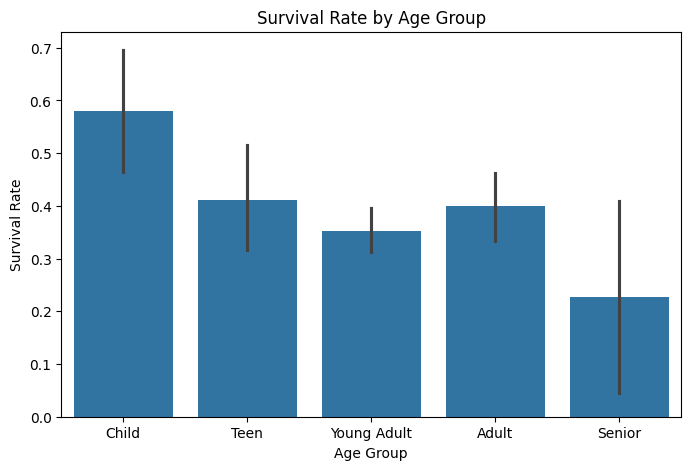

In [9]:
##QUESTION 3: Survival rate by age group

# Create Age Groups
bins = [0, 12, 19, 35, 60, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

age_survival = df.groupby('AgeGroup')['Survived'].mean()

print("\nSurvival Rate by Age Group:")
print(age_survival)

# Visualization
plt.figure(figsize=(8,5))
sns.barplot(x='AgeGroup', y='Survived', data=df)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

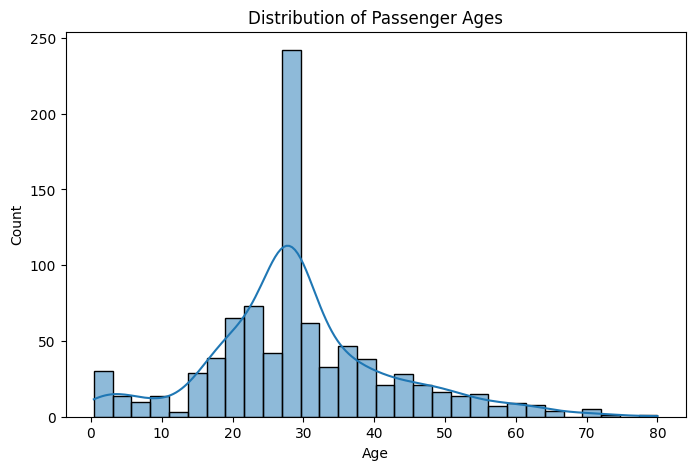

In [10]:
##HISTOGRAM OF PASSENGER AGES

plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()


In [11]:
##FINAL CONCLUSION

print("\nConclusion:")
print("1. Females had a higher survival rate than males.")
print("2. First-class passengers survived more than lower classes.")
print("3. Younger passengers had better survival chances.")
print("4. Data visualization helps understand survival patterns easily.")


Conclusion:
1. Females had a higher survival rate than males.
2. First-class passengers survived more than lower classes.
3. Younger passengers had better survival chances.
4. Data visualization helps understand survival patterns easily.
